# Hotel Booking Cancellation Prediction
## SPRINT 2: MODEL BUILDING & EVALUATION
**Goal: Build baseline and compare multiple models**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report,
ConfusionMatrixDisplay, roc_auc_score, roc_curve)

ROC AUC(Receiver Operating Characteristic (ROC) curve) (Area Under Curve)
It measures the Area Under the Receiver Operating Characteristic Curve. To work properly, you must pass probability estimates (e.g., predict_proba) or decision scores, not discrete predictions (e.g., predict)

In [4]:
pd.set_option("display.max_columns",None)

***Loading preprocessed from sprint 1***

In [5]:
df_pp = pd.read_csv(r'C:\Users\laksh\ML\ML Project\preprocessed_df')
print('Shape:',df_pp.shape)

Shape: (86940, 234)


In [6]:
df_pp.head()

,ohe__hotel_Resort Hotel,ohe__arrival_date_month_August,ohe__arrival_date_month_December,ohe__arrival_date_month_February,ohe__arrival_date_month_January,ohe__arrival_date_month_July,ohe__arrival_date_month_June,ohe__arrival_date_month_March,ohe__arrival_date_month_May,ohe__arrival_date_month_November,ohe__arrival_date_month_October,ohe__arrival_date_month_September,ohe__children_1.0,ohe__children_2.0,ohe__children_3.0,ohe__children_10.0,ohe__country_AGO,ohe__country_AIA,ohe__country_ALB,ohe__country_AND,ohe__country_ARE,ohe__country_ARG,ohe__country_ARM,ohe__country_ASM,ohe__country_ATA,ohe__country_ATF,ohe__country_AUS,ohe__country_AUT,ohe__country_AZE,ohe__country_BDI,ohe__country_BEL,ohe__country_BEN,ohe__country_BFA,ohe__country_BGD,ohe__country_BGR,ohe__country_BHR,ohe__country_BHS,ohe__country_BIH,ohe__country_BLR,ohe__country_BOL,ohe__country_BRA,ohe__country_BRB,ohe__country_BWA,ohe__country_CAF,ohe__country_CHE,ohe__country_CHL,ohe__country_CHN,ohe__country_CIV,ohe__country_CMR,ohe__country_CN,ohe__country_COL,ohe__country_COM,ohe__country_CPV,ohe__country_CRI,ohe__country_CUB,ohe__country_CYM,ohe__country_CYP,ohe__country_CZE,ohe__country_DEU,ohe__country_DJI,ohe__country_DMA,ohe__country_DNK,ohe__country_DOM,ohe__country_DZA,ohe__country_ECU,ohe__country_EGY,ohe__country_ESP,ohe__country_EST,ohe__country_ETH,ohe__country_FIN,ohe__country_FJI,ohe__country_FRA,ohe__country_FRO,ohe__country_GAB,ohe__country_GBR,ohe__country_GEO,ohe__country_GGY,ohe__country_GHA,ohe__country_GIB,ohe__country_GLP,ohe__country_GNB,ohe__country_GRC,ohe__country_GTM,ohe__country_GUY,ohe__country_HKG,ohe__country_HND,ohe__country_HRV,ohe__country_HUN,ohe__country_IDN,ohe__country_IMN,ohe__country_IND,ohe__country_IRL,ohe__country_IRN,ohe__country_IRQ,ohe__country_ISL,ohe__country_ISR,ohe__country_ITA,ohe__country_JAM,ohe__country_JEY,ohe__country_JOR,ohe__country_JPN,ohe__country_KAZ,ohe__country_KEN,ohe__country_KHM,ohe__country_KIR,ohe__country_KNA,ohe__country_KOR,ohe__country_KWT,ohe__country_LAO,ohe__country_LBN,ohe__country_LBY,ohe__country_LCA,ohe__country_LIE,ohe__country_LKA,ohe__country_LTU,ohe__country_LUX,ohe__country_LVA,ohe__country_MAC,ohe__country_MAR,ohe__country_MCO,ohe__country_MDG,ohe__country_MDV,ohe__country_MEX,ohe__country_MKD,ohe__country_MLI,ohe__country_MLT,ohe__country_MMR,ohe__country_MNE,ohe__country_MOZ,ohe__country_MRT,ohe__country_MUS,ohe__country_MWI,ohe__country_MYS,ohe__country_MYT,ohe__country_NAM,ohe__country_NCL,ohe__country_NGA,ohe__country_NIC,ohe__country_NLD,ohe__country_NOR,ohe__country_NPL,ohe__country_NZL,ohe__country_OMN,ohe__country_PAK,ohe__country_PAN,ohe__country_PER,ohe__country_PHL,ohe__country_PLW,ohe__country_POL,ohe__country_PRI,ohe__country_PRT,ohe__country_PRY,ohe__country_PYF,ohe__country_QAT,ohe__country_ROU,ohe__country_RUS,ohe__country_RWA,ohe__country_SAU,ohe__country_SDN,ohe__country_SEN,ohe__country_SGP,ohe__country_SLE,ohe__country_SLV,ohe__country_SMR,ohe__country_SRB,ohe__country_STP,ohe__country_SUR,ohe__country_SVK,ohe__country_SVN,ohe__country_SWE,ohe__country_SYC,ohe__country_SYR,ohe__country_TGO,ohe__country_THA,ohe__country_TJK,ohe__country_TMP,ohe__country_TUN,ohe__country_TUR,ohe__country_TWN,ohe__country_TZA,ohe__country_UGA,ohe__country_UKR,ohe__country_UMI,ohe__country_URY,ohe__country_USA,ohe__country_UZB,ohe__country_VEN,ohe__country_VGB,ohe__country_VNM,ohe__country_ZAF,ohe__country_ZMB,ohe__country_ZWE,ohe__market_segment_Complementary,ohe__market_segment_Corporate,ohe__market_segment_Direct,ohe__market_segment_Groups,ohe__market_segment_Offline TA/TO,ohe__market_segment_Online TA,ohe__reserved_room_type_B,ohe__reserved_room_type_C,ohe__reserved_room_type_D,ohe__reserved_room_type_E,ohe__reserved_room_type_F,ohe__reserved_room_type_G,ohe__reserved_room_type_H,ohe__reserved_room_type_L,ohe__reserved_room_type_P,ohe__assigned_room_type_B,ohe__assigned_room_type_C,ohe__assigned_room_type_D,ohe__assigned_room_type_E,ohe__assigned_room_type_F,ohe__assigned_room_ty

### Step 1: Define Features and Target

In [7]:
X = df_pp.drop('remainder__is_canceled',axis=1)
y = df_pp['remainder__is_canceled']

In [8]:
X.drop(y[y.isna()].index,inplace=True)
y.drop(y[y.isna()].index,inplace=True)


In [9]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print(f"\nCancellation rate: {y.mean()*100:.2f}%")

Feature shape: (86940, 233)
Target shape: (86940,)

Target distribution:
remainder__is_canceled
0.0    62953
1.0    23987
Name: count, dtype: int64

Cancellation rate: 27.59%


### Train-Test-Split(80-20)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [11]:
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n",  y_test.value_counts())

X_train: (69552, 233)
X_test:  (17388, 233)
y_train distribution:
 remainder__is_canceled
0.0    50362
1.0    19190
Name: count, dtype: int64
y_test distribution:
 remainder__is_canceled
0.0    12591
1.0     4797
Name: count, dtype: int64


---
### Step 1: Baseline Models

###  Logistic Regression

In [12]:
lr_baseline = LogisticRegression(max_iter=1000,random_state=42)

lr_baseline.fit(X_train,y_train)
y_pred = lr_baseline.predict(X_test)
print("---------------Logistic Regression (Baseline)-----------")
print('Accuracy',accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test, lr_baseline.predict_proba(X_test)[:,1]))

---------------Logistic Regression (Baseline)-----------
Accuracy 0.7708764665286404
              precision    recall  f1-score   support

         0.0       0.79      0.92      0.85     12591
         1.0       0.65      0.38      0.48      4797

    accuracy                           0.77     17388
   macro avg       0.72      0.65      0.66     17388
weighted avg       0.75      0.77      0.75     17388



### KNN

In [13]:
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)
print("--------------- KNN -----------")
print('Accuracy',accuracy_score(y_test,y_pred_knn))
print(classification_report(y_test, y_pred_knn))

--------------- KNN -----------
Accuracy 0.7554060271451576
              precision    recall  f1-score   support

         0.0       0.82      0.85      0.83     12591
         1.0       0.56      0.52      0.54      4797

    accuracy                           0.76     17388
   macro avg       0.69      0.68      0.69     17388
weighted avg       0.75      0.76      0.75     17388



### Naive Bayes

In [14]:
nb = GaussianNB()
nb.fit(X_train,y_train)
y_pred_nb = nb.predict(X_test)
print("--------------- Naive Bayes -----------")
print('Accuracy',accuracy_score(y_test,y_pred_nb))
print(classification_report(y_test, y_pred_nb))

--------------- Naive Bayes -----------
Accuracy 0.2999194847020934
              precision    recall  f1-score   support

         0.0       0.89      0.04      0.07     12591
         1.0       0.28      0.99      0.44      4797

    accuracy                           0.30     17388
   macro avg       0.58      0.51      0.26     17388
weighted avg       0.72      0.30      0.17     17388



### Decision Tree

In [15]:
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)
print("--------------- Decision Tree -----------")
print('Accuracy',accuracy_score(y_test,y_pred_dt))
print(classification_report(y_test, y_pred_dt))

--------------- Decision Tree -----------
Accuracy 0.7496549344375432
              precision    recall  f1-score   support

         0.0       0.83      0.82      0.83     12591
         1.0       0.55      0.56      0.55      4797

    accuracy                           0.75     17388
   macro avg       0.69      0.69      0.69     17388
weighted avg       0.75      0.75      0.75     17388



### Random Forest

In [16]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train) 
y_pred_rf = rf.predict(X_test)
print("--------------- Random Forest -----------")
print('Accuracy',accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test, y_pred_rf))

--------------- Random Forest -----------
Accuracy 0.7958937198067633
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86     12591
         1.0       0.67      0.52      0.58      4797

    accuracy                           0.80     17388
   macro avg       0.75      0.71      0.72     17388
weighted avg       0.79      0.80      0.79     17388



---
### Step 2,3: Train Multiple Models and Model Evaluation

**Define all models**

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'knn': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

**Train all models and collect metrics**

In [18]:
results = []

for name, model in models.items():
    print(f"Training: {name} ...")
    model.fit(X_train, y_train)

    y_pred       = model.predict(X_test)
    y_pred_train = model.predict(X_train)


    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test,  y_pred)
    prec      = precision_score(y_test, y_pred)
    rec       = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    overfit   = 'Yes' if (train_acc - test_acc) > 0.05 else 'No'

    results.append({
        'Model':          name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy':  round(test_acc,  4),
        'Precision':      round(prec,      4),
        'Recall':         round(rec,       4),
        'F1 Score':       round(f1,        4),
        'Overfitting?':   overfit
    })

print("\nAll models trained!")

Training: Logistic Regression ...
Training: knn ...
Training: Naive Bayes ...
Training: Decision Tree ...
Training: Random Forest ...

All models trained!


In [19]:
# Model Comparison Table
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)

### Step 4: Overfitting & Underfitting Check

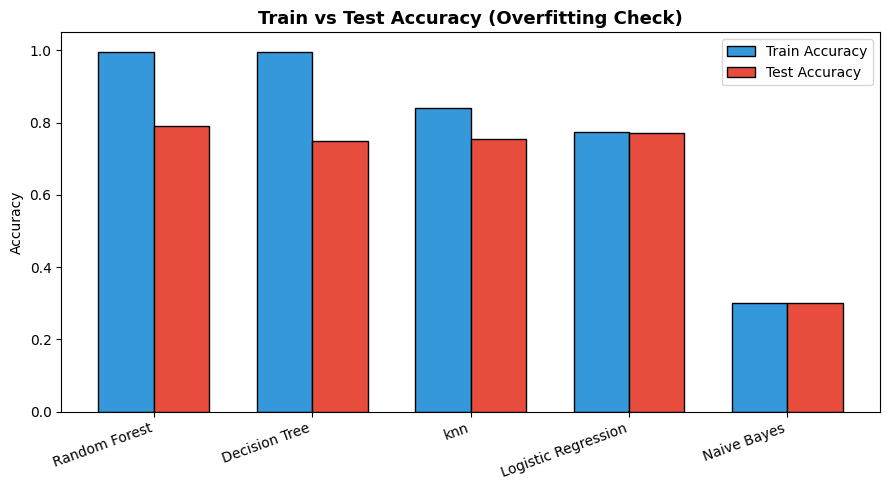


Overfitting Summary:
              Model  Train Accuracy  Test Accuracy Overfitting?
      Random Forest          0.9954         0.7909          Yes
      Decision Tree          0.9954         0.7484          Yes
                knn          0.8397         0.7554          Yes
Logistic Regression          0.7738         0.7709           No
        Naive Bayes          0.3013         0.2999           No


In [20]:
# Train vs Test accuracy comparison
x_pos = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_pos - width/2, results_df['Train Accuracy'], width, label='Train Accuracy', color='#3498db', edgecolor='black')
ax.bar(x_pos + width/2, results_df['Test Accuracy'],  width, label='Test Accuracy',  color='#e74c3c', edgecolor='black')

ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy (Overfitting Check)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nOverfitting Summary:")
print(results_df[['Model', 'Train Accuracy', 'Test Accuracy', 'Overfitting?']].to_string(index=False))

### Step 5: Model Comparison Table

In [21]:
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Overfitting?
4,Random Forest,0.9954,0.7909,0.6544,0.5134,0.5754,Yes
3,Decision Tree,0.9954,0.7484,0.5436,0.5481,0.5458,Yes
1,knn,0.8397,0.7554,0.5618,0.5153,0.5376,Yes
0,Logistic Regression,0.7738,0.7709,0.6452,0.3765,0.4755,No
2,Naive Bayes,0.3013,0.2999,0.2811,0.9875,0.4377,No
